![](../images/logos/KIEPSKIES.jpg)
# Feature Extraction on GeoSpatial Data
## **Introduction**

When working with geospatial data, we often don’t need the entire dataset—just a specific portion based on location, attributes, or spatial relationships. Imagine you have a dataset of wells across San Francisco, but you’re only interested in wells located within a particular district or above a certain depth level. How do you filter them? That’s where subsetting and extraction come in! 🗺️🔍

In this chapter, we will dive into three powerful techniques:

- Clipping – Extracting data within a defined boundary
- Selecting by attribute – Filtering based on specific values (e.g., wells deeper than 50 meters)
- Selecting by location – Finding features based on their spatial relationship to another dataset

But first, let’s get set up! Run the code cell below to import the necessary libraries:

In [1]:
# Import modules
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Polygon
import warnings

# Supress future warnings 
warnings.filterwarnings("ignore")

## **Loading and Reprojecting GeoSpatial Data**

Before we start working with our geospatial data, we need to load the datasets and ensure they are in the correct coordinate reference system (CRS). We'll be using two datasets:

- *San Francisco Bay Area County Boundaries* – Defines the county borders in the Bay Area.
- *Well Locations* – Shows groundwater wells in and around the Bay Area (within a 50 km buffer).

Let’s load these datasets!

In [3]:
# Load data

# County boundaries
# Source: https://opendata.mtc.ca.gov/datasets/san-francisco-bay-region-counties-clipped?geometry=-125.590%2C37.123%2C-119.152%2C38.640
counties = gpd.read_file("../data/open-GIS/region_county/region_county.shp")

# Well locations
# Source: https://gis.data.ca.gov/datasets/3a3e681b894644a9a95f9815aeeeb57f_0?geometry=-123.143%2C36.405%2C-119.230%2C37.175
# Modified by author so that only the well locations within the counties and the surrounding 50 km were kept
wells = gpd.read_file("../data/open-GIS/i08_GroundwaterStations_EnterpriseWaterManagement/i08_GroundwaterStations_EnterpriseWaterManagement.shp")

<span style="color: #00008B;">**Why Do We Need to Reproject Data?**</span>

Every geospatial dataset comes with a coordinate reference system (CRS) that defines how locations are mapped on the Earth. Different datasets may have different CRSs, so to analyze them together, we must reproject them into the same CRS.

For this project, we’ll use NAD83(HARN) / California Zone 3 (EPSG:2768), which is a projected coordinate system commonly used for California mapping.

In [4]:
# Reproject data to NAD83(HARN) / California Zone 3
# https://spatialreference.org/ref/epsg/2768/
proj = 2768
counties = counties.to_crs(proj)
wells = wells.to_crs(proj)

In [5]:
counties.head()

,fipst,fipco,coname,geometry
0,06,097,None,"POLYGON ((1787066.56 704090.104, 1787074.707 7..."
1,06,075,None,"MULTIPOLYGON (((1828026.871 650402.153, 182677..."
2,06,041,None,"POLYGON ((1798906.44 656381.811, 1798982.726 6..."
3,06,055,None,"POLYGON ((1829172.531 746544.267, 1827998.596 ..."
4,06,095,None,"POLYGON ((1863162.718 702681.284, 1862854.907 ..."


In [6]:
wells.head()

,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
0,1,344238N1196128W001,3-23,None,61095,None,next to house in walled region by trash,Residential,Single Well,435.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{DB05DE98-CBFF-4537-A2C4-3420D4E29784},POINT (2081683.705 269860.261)
1,2,344218N1196224W001,3-24,None,61096,None,near large avo tree and road,Residential,Single Well,325.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{51656FF0-0034-4E7E-B8F0-4DB552122841},POINT (2080799.161 269634.143)
2,3,344192N1196477W001,3-27,None,61097,None,between house and garage in back,Irrigation,Single Well,280.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{91C76CBD-6EAF-421A-A8D0-0CAED39965B7},POINT (2078475.315 269315.999)
3,4,344202N1196262W001,3-28,None,61098,None,in parking lot,Irrigation,Single Well,165.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{1D8B05DC-D338-4A03-9358-2A88ECBA54A8},POINT (2080449.112 269454.201)
4,5,344317N1195730W001,4-4,None,61099,None,above garage and rec building,Irrigation,Single Well,975.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{D0BB90BC-2DD3-441F-9A5C-11F5A9141EB8},POINT (2085336.365 270780.108)


## **Creating a Custom Bounding Box**

Sometimes, we don’t want to work with the entire dataset—just a specific region. To do this, we create a bounding box (rectangle) to extract data within its boundaries.

💡 Want to create your own bounding box? Use BBox Finder to generate coordinates for a custom area!

Let's define a rectangular region of interest over the Bay Area:

In [7]:
# Create list of coordinate pairs
coordinates = [[1790787, 736108], [1929652, 736108], [1929652, 598414], [1790787, 598414]]

# Create a Shapely polygon from the coordinate-tuple list
poly_shapely = Polygon(coordinates)

# Create a dictionary with needed attributes and required geometry column
attributes_df = {'Attribute': ['name1'], 'geometry': poly_shapely}

# Convert shapely object to a GeoDataFrame
poly = gpd.GeoDataFrame(attributes_df, geometry = 'geometry', crs = "EPSG:2768")

Before we dive into subsetting and extracting data, let's set up some helper functions to make it easier to view tables and visualize maps.

<span style="color: #00008B;">**Why use functions?**</span>

- Reusability: We can call these functions anytime instead of rewriting code.
- Readability: They make the code more organized.
- Flexibility: We can easily modify them to adjust the way we display data.

The first function, `display_table()`, will help us quickly examine any dataset by:

- Showing the first and last two rows of the dataset
- Displaying the total number of rows and columns

In [8]:
def display_table(table_name, attribute_table):
    '''Display the first and last five rows of attribute table.'''

    # Print title
    print("Attribute Table: {}".format(table_name))

    # Print number of rows and columns
    print("\nTable shape (rows, columns): {}".format(attribute_table.shape))

    # Display first two rows of attribute table
    print("\nFirst two rows:")
    display(attribute_table.head(2))

    # Display last two rows of attribute table
    print("\nLast two rows:")
    display(attribute_table.tail(2))

Lets try them out!

In [9]:
display_table("County Boundaries", counties)
display_table("Well Locations", wells)

Attribute Table: County Boundaries

Table shape (rows, columns): (9, 4)

First two rows:


,fipst,fipco,coname,geometry
0,06,097,None,"POLYGON ((1787066.56 704090.104, 1787074.707 7..."
1,06,075,None,"MULTIPOLYGON (((1828026.871 650402.153, 182677..."



Last two rows:


,fipst,fipco,coname,geometry
7,06,001,None,"POLYGON ((1842981.676 635473.387, 1843183.737 ..."
8,06,081,None,"POLYGON ((1815689.824 622752.196, 1815650.806 ..."


Attribute Table: Well Locations

Table shape (rows, columns): (46879, 28)

First two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
0,1,344238N1196128W001,3-23,None,61095,None,next to house in walled region by trash,Residential,Single Well,435.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{DB05DE98-CBFF-4537-A2C4-3420D4E29784},POINT (2081683.705 269860.261)
1,2,344218N1196224W001,3-24,None,61096,None,near large avo tree and road,Residential,Single Well,325.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{51656FF0-0034-4E7E-B8F0-4DB552122841},POINT (2080799.161 269634.143)



Last two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
46877,46878,346292N1175507W001,06N06W07B001S,06N06W07B001S,5748,None,None,Unknown,Unknown,NaN,...,VOLUNTARY,Department of Water Resources,United States Geological Survey,None,2023-09-26,None,DWR EWM DB,2024-09-25,{E0CEA165-79F6-4F66-B428-023B0A0F263D},POINT (2270776.916 296556.086)
46878,46879,341286N1172740W001,01N04W35L001S,01N04W35L001S,2400,None,None,Unknown,Unknown,NaN,...,VOLUNTARY,Department of Water Resources,United States Geological Survey,None,2023-09-26,None,DWR EWM DB,2024-09-25,{E2D46F76-6F98-4F79-93CB-3D3E640920CD},POINT (2298088.145 241805.383)


The second function, `plot_df()`, is used to visualize our geospatial data.

What does this function do?

- Plots the dataset while highlighting selected data
- Uses different colors for points (wells) and polygons (counties)
- Adds a custom boundary box if provided

In [10]:
def plot_df(result_name, result_df, result_geom_type, area = None):
    '''Plot the result on a map and add the outlines of the original shapefiles.'''

    # Create subplots
    fig, ax = plt.subplots(1, 1, figsize = (10, 10))

    # Plot data depending on vector type
    # For points
    if result_geom_type == "point":

        # Plot data
        counties.plot(ax = ax, color = 'none', edgecolor = 'dimgray')
        wells.plot(ax = ax, marker = 'o', color = 'dimgray', markersize = 3)
        result_df.plot(ax = ax, marker = 'o', color = 'dodgerblue', markersize = 3)

    # For polygons
    else:

        # Plot overlay data
        result_df.plot(ax = ax, cmap = 'Set2', edgecolor = 'black')

        # Plot outlines of original shapefiles
        counties.plot(ax = ax, color = 'none', edgecolor = 'dimgray')

    # Add additional outlined boundary if specified
    if area is not None:

        # Plot data
        area.plot(ax = ax, color = 'none', edgecolor = 'lightseagreen', linewidth = 3)

    # Else, pass
    else:
        pass

    # Stylize plots
    plt.style.use('bmh')

    # Set title
    ax.set_title(result_name, fontdict = {'fontsize': '15', 'fontweight' : '3'})

Now, let's use our function to see what the San Francisco Bay Area dataset looks like.

Text(0.5, 1.0, 'San Francisco Bay Area')

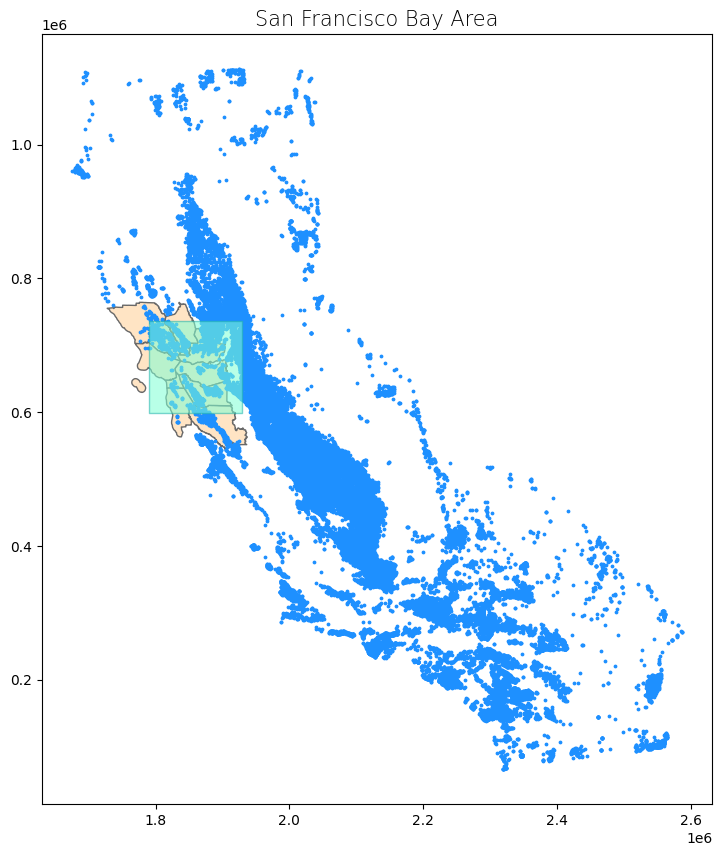

In [11]:
# Create subplots
fig, ax = plt.subplots(1, 1, figsize = (10, 10))

# Plot data
counties.plot(ax = ax, color = 'bisque', edgecolor = 'dimgray')
wells.plot(ax = ax, marker = 'o', color = 'dodgerblue', markersize = 3)
poly.plot(ax = ax, color = 'aquamarine', edgecolor = 'lightseagreen', alpha = 0.55)

# Stylize plots
plt.style.use('bmh')

# Set title
ax.set_title('San Francisco Bay Area', fontdict = {'fontsize': '15', 'fontweight' : '3'})

## **Clipping Spatial Polygons**

What is Clipping?
Clipping extracts and keeps only the geometries within the extent of another feature. Think of it like using a cookie cutter—you keep the part inside the cutter and discard the rest!

In GeoPandas, we use `clip()` to extract features based on another boundary.

- The first parameter is the vector to be clipped.
- The second parameter is the boundary defining the clip.
- The output retains all attributes from the original dataset.

### **Clipping County Boundaries**

We will clip the Bay Area counties to match our predefined bounding rectangle (`poly`).

,fipst,fipco,coname,geometry
6,06,085,None,"POLYGON ((1849513.743 598437.644, 1849516.319 ..."
8,06,081,None,"POLYGON ((1824620.608 598957.373, 1824615.39 5..."
7,06,001,None,"POLYGON ((1842904.446 635585.861, 1842846.78 6..."
1,06,075,None,"POLYGON ((1828782.706 650763.837, 1829836.435 ..."
5,06,013,None,"POLYGON ((1844547.064 657302.253, 1844531.633 ..."
2,06,041,None,"POLYGON ((1791829.77 702650.089, 1791932.215 7..."
4,06,095,None,"POLYGON ((1863138.714 702814.904, 1862870.072 ..."
0,06,097,None,"POLYGON ((1813605.103 736060.767, 1813555.59 7..."
3,06,055,None,"POLYGON ((1856673.293 736098.588, 1856691.032 ..."


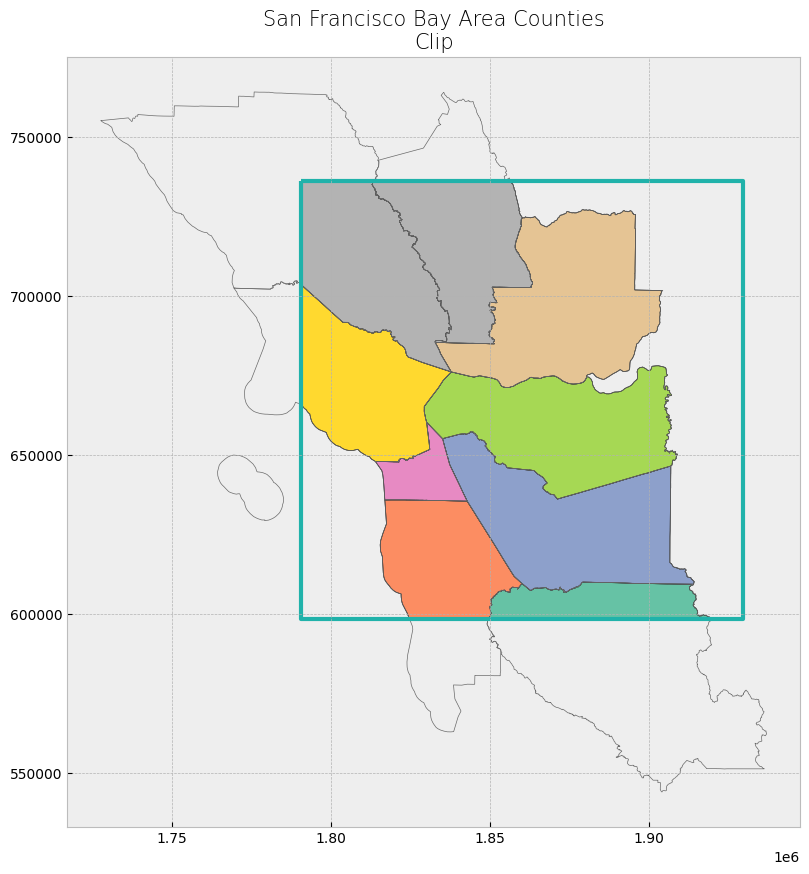

In [12]:
# Clip data
clip_counties = gpd.clip(counties, poly)

# Display attribute table
display(clip_counties)

# Plot clip
plot_df(result_name = "San Francisco Bay Area Counties\nClip", result_df = clip_counties, result_geom_type = "polygon", area = poly)

**Observe how only the counties within the rectangle remain colored!**

### **Clipping Well Locations**

We can clip points the same way! Now, let's clip the wells dataset to the same boundary (`poly`).

,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
40579,40580,374517N1224295W001,05S05W32K001M,05S05W32K001M,7008,None,None,Unknown,Unknown,38.0,...,VOLUNTARY,Department of Water Resources,Department of Water Resources,None,2023-09-26,None,DWR EWM DB,2024-09-25,{E097559B-CF5D-48CF-B367-B95C98C695EE},POINT (1829296.287 607379.559)
21229,21230,374643N1224317W001,Pilarcitos Creek W1,05S05W29P001M,40046,20202,Kelly Street and Church Street Area,Irrigation,Single Well,84.0,...,CASGEM,Department of Water Resources,Department of Water Resources,Coastside County Water District received permi...,2024-07-16,None,DWR EWM DB,2024-09-25,{7B320EB7-4437-4AAC-8CBE-93A7F90C9FAE},POINT (1829130.54 608781.622)
23677,23678,374011N1221231W001,06S02W19B002,06S02W19B002M,56480,None,"End of Estrallita Take the bike path, the well...",Observation,Single Well,295.0,...,SGMA,Santa Clara Valley Water District - Santa Clara,Santa Clara Valley Water District,Coordinate method is combination of GPS and di...,2023-06-06,None,DWR EWM DB,2024-09-25,{B7242DD5-F3A7-49FD-8D63-6723D787E015},POINT (1856307.007 601251.365)
8077,8078,374069N1220886W001,06S02W16L021,06S02W16L021M,47609,0914620,7N SAN LUIS/130W FARLEY,Observation,Single Well,40.0,...,SGMA,Santa Clara Valley Water District - Santa Clara,Santa Clara Valley Water District,Coordinate method is combination of GPS and di...,2023-06-06,None,DWR EWM DB,2024-09-25,{FC0AD1AF-F079-401C-B130-6DA1ACC5781D},POINT (1859366.708 601842.634)
23863,23864,374090N1221168W001,06S02W18J001,06S02W18J001M,47610,184218,528N MILLER AVE/137E MONROE DR,Observation,Single Well,46.0,...,SGMA,Santa Clara Valley Water District - Santa Clara,Santa Clara Valley Water District,Coordinate method is combination of GPS and di...,2023-06-06,None,DWR EWM DB,2024-09-25,{C4A0BD27-F3C5-43E9-A1A7-5FE7D56BEAF1},POINT (1856912.911 602135.505)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3528,3529,386222N1214458W001,SAC-143,09N05E21E002M,52237,77994,None,Other,Single Well,330.0,...,VOLUNTARY,Sacramento Groundwater Authority,Sacramento Groundwater Authority,None,2021-12-15,None,DWR EWM DB,2024-09-25,{6987140F-7C5C-4A0F-8AC6-05ADF7E453AB},POINT (1917633.571 735950.159)
3521,3522,386220N1214766W001,SAC-093,09N05E19F001M,52221,21011,None,Other,Single Well,328.0,...,VOLUNTARY,Sacramento Groundwater Authority,Sacramento Groundwater Authority,None,2021-12-15,None,DWR EWM DB,2024-09-25,{9C449B28-434C-4C8A-823D-BE6724F11EFB},POINT (1914951.105 735960.836)
3481,3482,386229N1214138W001,SSWD 43,09N05E22A001M,52410,None,Edison/Truax,Other,Single Well,390.0,...,VOLUNTARY,Department of Water Resources,Sacramento Groundwater Authority,None,2021-12-15,None,DWR EWM DB,2024-09-25,{4C06134D-F4E2-4400-B9B0-061D2AE86173},POINT (1920423.042 735999.713)
7720,7721,386238N1213744W001,24,None,51634,None,None,Unknown,Single Well,360.0,...,VOLUNTARY,Department of Water Resources,Department of Water Resources,None,2021-12-15,None,DWR EWM DB,2024-09-25,{2118EE76-505C-4361-B6B1-29366B07D213},POINT (1923853.948 736074.4)


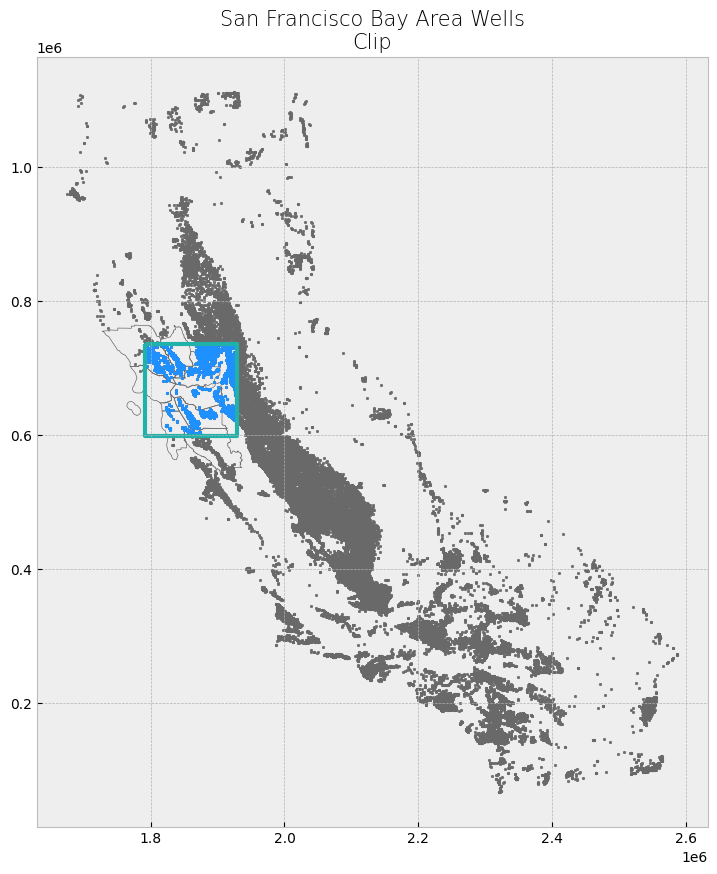

In [13]:
# Clip data
clip_wells = gpd.clip(wells, poly)

# Display attribute table
display(clip_wells)

# Plot clip
plot_df(result_name = "San Francisco Bay Area Wells\nClip", result_df = clip_wells, result_geom_type = "point", area = poly)

*Notice how only wells within the selected region remain visible!*

## **Select Location by Attributes**

In [ ]:
# Display attribute table
display(wells.head(2))

In [ ]:
# Select wells that are public supply
wells_public = wells[(wells["WELL_USE"] == "Public Supply")]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells - Public Supply", attribute_table = wells_public)

In [ ]:
# Select wells that are public supply and have a depth greater than 50 ft
wells_public_deep = wells[(wells["WELL_USE"] == "Public Supply") & (wells["WELL_DEPTH"] > 50)]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells - Public Supply with Depth Greater than 50 ft", attribute_table = wells_public_deep)

In [ ]:
# Select wells that are public supply and have a depth greater than 50 ft OR are residential
wells_public_deep_residential = wells[((wells["WELL_USE"] == "Public Supply") & (wells["WELL_DEPTH"] > 50)) | (wells["WELL_USE"] == "Residential")]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells - Public Supply with Depth Greater than 50 ft or Residential", attribute_table = wells_public_deep_residential)

# Select by Location
## Shapely Vector

In [ ]:
# Select wells that fall within Shapely rectangle
wells_within_rect_shapely = wells[wells.within(poly_shapely)]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells within a User-Defined Rectangle", attribute_table = wells_within_rect_shapely)

# Plot selection
plot_df(result_name = "San Francisco Bay Area Wells within a User-Defined Rectangle", result_df = wells_within_rect_shapely, result_geom_type = "point", area = poly)

In [ ]:
# Select the Santa Clara County boundary
sc_county = counties[counties["coname"] == "Santa Clara County"]

# Subset the GeoDataFrame by checking which wells are within Santa Clara County's Shapely object
wells_within_sc_shapely = wells[wells.within(sc_county.geometry.values[0])]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells within Santa Clara County", attribute_table = wells_within_sc_shapely)

# Plot selection
plot_df(result_name = "San Francisco Bay Area Wells within Santa Clara County", result_df = wells_within_sc_shapely, result_geom_type = "point", area = sc_county)